# Custom algorithm approach 2

This notebook explores the use of an altenative algorithm to generate ontologies based on the conclusion from naive approach.

We will explore the definition of comunities.

In [1]:
%load_ext autoreload
%autoreload 2

## Libraries
import sys
from pathlib import Path
import pandas as pd
import json
import math
import numpy as np
import community as community_louvain
import matplotlib.pyplot as plt
import networkx as nx

sys.path.insert(0, str(Path.cwd().parent))
from src.services import ChatGpt
from src.services import clustering


In [ ]:
## Setup parameters

domain = "Star Trek"
initial_term_seed = 20
similarity_filter = 80 # cuts the relationships that count from similarity taxonomy
minimum_confidence_treshold = 0.85

ucb1_exploration_constant = 2
k_similarity_treshold = 20
g_min_reward_treshold = 10
max_iterations = 10


---
## Step 1 - seeds

Get first batch (seed) and calculate similarities

In [3]:
agent = ChatGpt()
agent.model = "gpt-4o-mini"


In [4]:
terms_list_str = agent.chat(
    instructions="You are a taxonomy and ontology expert. Provide concise and accurate responses based on the user's queries.",
    input=f"""
        Provide a list of {initial_term_seed} categories, terms or words closely related to domain or topic and using the provided terms as reference.
        
        - the domain or topic is: {domain}
        
        Your output should be a json array with only the category names, with a small text describing the term and relation to theme. 
        This categories should include the given terms and be closely related to the domain or topic.
        Do not encapsulate the output in code blocks.
        
        Example output:
        [
            "category1": "small description1",
            "category2": "small description12",
            ...            "category100":"small description100"
        ]
        
    """
)

In [5]:
terms_list_json = json.loads(terms_list_str)
terms_list_flat = [(list(d.keys())[0], list(d.values())[0]) for d in terms_list_json]
terms_list_df = pd.DataFrame(terms_list_flat, columns=["term", "description"])

In [6]:
terms_pair = pd.merge(terms_list_df, terms_list_df, how='cross')
terms_pair = terms_pair.drop(terms_pair[terms_pair['term_x'] == terms_pair['term_y']].index) # We don't need to analyse a term with itself

In [7]:
terms_pair['similarity'] = terms_pair.apply(
    lambda row: agent.get_similarity_with_descriptions(
        term_x=row['term_x'],
        description_x=row['description_x'],
        term_y=row['term_y'],
        description_y=row['description_y']
    )['similarity'],
    axis=1
)

---
## Step 2: Generate Semantic Similarity Graph and detect initial communities 

In [8]:
terms_pair

,term_x,description_x,term_y,description_y,similarity
1,Starfleet,The main exploration and defense service of th...,Klingons,A prominent warrior species known for their st...,70
2,Starfleet,The main exploration and defense service of th...,Borg,A cybernetic species that assimilates other cu...,70
3,Starfleet,The main exploration and defense service of th...,Spock,"A half-Vulcan, half-Human character known for ...",70
4,Starfleet,The main exploration and defense service of th...,Warp Drive,The faster-than-light travel system enabling s...,70
5,Starfleet,The main exploration and defense service of th...,Phasers,Energy-based weapons used by Starfleet personnel.,75
...,...,...,...,...,...
394,Data,An android with advanced intelligence and curi...,Holodeck,A virtual reality environment used for trainin...,50
395,Data,An android with advanced intelligence and curi...,Transwarp Technology,An advanced form of faster-than-light travel i...,25
396,Data,An android with advanced intelligence and curi...,Q Continuum,A race of god-like beings that manipulate spac...,35
397,Data,An android with advanced intelligence and curi...,Bajoran,An important humanoid species often depicted i...,30


In [12]:

similarity_graph = clustering.build_similarity_graph(terms_pair, similarity_filter)
#similarity_graph['distance'] = 100 - similarity_graph['similarity']

All terms (20): ['Bajoran', 'Borg', 'Cardassians', 'Data', 'Federation', 'Holodeck', 'Klingons', 'Phasers', 'Philosophy', 'Q Continuum', 'Romulans', 'Spock', 'Starfleet', 'Starship Enterprise', 'Time Travel', 'Transporter', 'Transwarp Technology', 'Tricorder', 'Vulcans', 'Warp Drive']

Edges added (threshold >= 80):
  Cardassians -- Bajoran (weight: 80.00)
  Cardassians -- Klingons (weight: 80.00)
  Cardassians -- Romulans (weight: 80.00)
  Transwarp Technology -- Warp Drive (weight: 80.00)
  Data -- Spock (weight: 80.00)
  Federation -- Starfleet (weight: 85.00)
  Federation -- Romulans (weight: 80.00)
  Starship Enterprise -- Starfleet (weight: 85.00)
  Starship Enterprise -- Warp Drive (weight: 80.00)
  Spock -- Vulcans (weight: 85.00)

Summary: 20 nodes, 10 edges


In [13]:
len(similarity_graph)

20

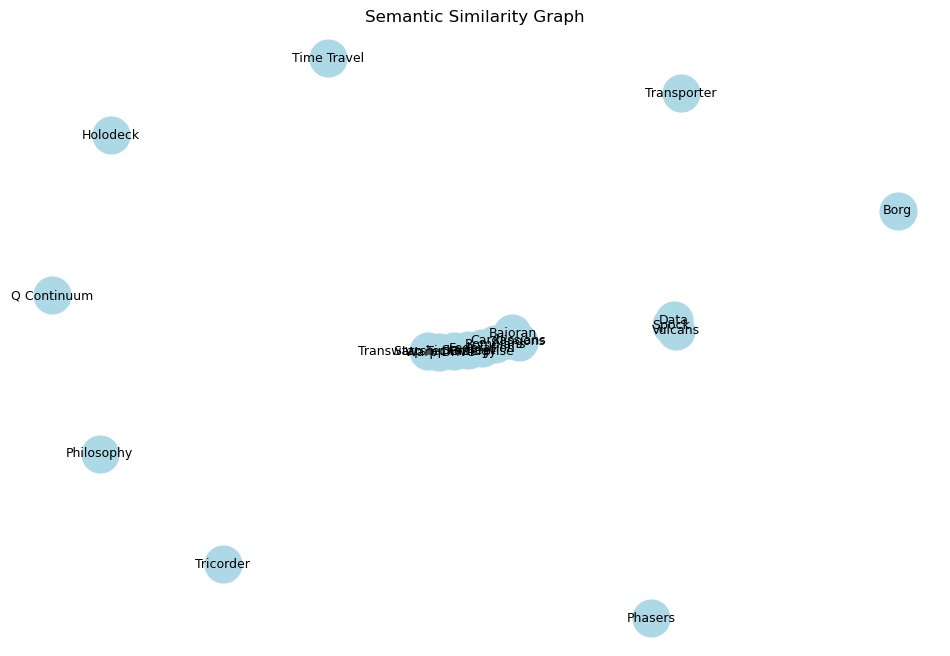

In [14]:
plt.figure(figsize=(12, 8))
pos = nx.spring_layout(similarity_graph, seed=42) 
nx.draw_networkx_nodes(similarity_graph, pos, node_size=700, node_color='lightblue')
nx.draw_networkx_edges(similarity_graph, pos, width=1.0, alpha=0.7)
nx.draw_networkx_labels(similarity_graph, pos, font_size=9, font_family="sans-serif")
plt.title("Semantic Similarity Graph")
plt.axis('off')
plt.show()

In [20]:
communities = community_louvain.best_partition(similarity_graph, weight='weight')

# Print communities
for community_id in set(communities.values()):
    members = [node for node, cid in communities.items() if cid == community_id]
    print(f"Community {community_id}: {members}")

Community 0: ['Phasers']
Community 1: ['Borg']
Community 2: ['Transwarp Technology', 'Starship Enterprise', 'Warp Drive', 'Starfleet']
Community 3: ['Transporter']
Community 4: ['Holodeck']
Community 5: ['Data', 'Spock', 'Vulcans']
Community 6: ['Tricorder']
Community 7: ['Time Travel']
Community 8: ['Cardassians', 'Klingons', 'Federation', 'Romulans', 'Bajoran']
Community 9: ['Philosophy']
Community 10: ['Q Continuum']


---
## Step 3: Infer initial ontology

In [27]:
import json
import re

def induce_local_ontology(communities, terms_list_df, agent, domain, minimum_confidence_threshold=0.95):
    """
    Induce local ontology by classifying relationships between terms in communities.
    
    Args:
        communities: Dict mapping terms to community IDs
        terms_list_df: DataFrame with 'term' and 'description' columns
        agent: Chat agent for LLM interaction
        domain: The domain context (e.g., "software engineering", "biology")
        minimum_confidence_threshold: Minimum confidence for including relations (0-1)
    """
    # Group terms by community
    grouped_communities = {}
    for term, cid in communities.items():
        grouped_communities.setdefault(cid, []).append(term)

    results = {}

    for cid, terms in grouped_communities.items():
        print(f"\nProcessing community {cid} with {len(terms)} terms...")
        
        # Skip communities with only 1 term (no pairs to compare)
        if len(terms) < 2:
            print(f"Skipping community {cid}: only {len(terms)} term(s)")
            results[cid] = []
            continue
        
        # Fetch descriptions
        descs = []
        for term in terms:
            desc = terms_list_df.loc[terms_list_df['term'] == term, 'description'].values
            if len(desc) > 0:
                descs.append(f"- {term}: {desc[0]}")
            else:
                descs.append(f"- {term}: [No description found]")

        # Convert threshold to percentage for clarity
        threshold_pct = minimum_confidence_threshold * 100

        prompt = f"""You are a domain expert in {domain}. Your task is to classify relationships between pairs of DIFFERENT terms based STRICTLY on the definitions below.

DOMAIN CONTEXT: {domain}

RELATIONSHIP DEFINITIONS (use ONLY these three categories):

1. SIMILARITY: Terms represent equivalent, analogous, or interchangeable concepts within {domain}.
   - They describe the same or very similar phenomena
   - They could be synonyms, near-synonyms, or alternate names
   - They belong to the same group/concept
   - Example: "vehicle" and "automobile"

2. COMPOSITION: One term is a structural component, part, or element of the other within {domain}.
   - Clear part-whole relationship (X is part of Y)
   - Hierarchical containment (X belongs to Y)
   - NOT similarity, NOT metaphorical relationships
   - Example: "engine" is composition of "car"

3. NO RELATION: Terms have no meaningful similarity or compositional relationship in {domain}.
   - They are distinct concepts
   - No direct structural or semantic connection
   - Default classification when uncertain

TERMS TO ANALYZE:
{chr(10).join(descs)}

CLASSIFICATION RULES:
- Analyze ONLY the terms provided above (do not invent terms)
- Evaluate each unique pair exactly once
- **NEVER compare a term with itself** (source must differ from target)
- Consider the {domain} context for all classifications
- Use "no relation" as the default when uncertain
- Base classifications on the provided descriptions

OUTPUT REQUIREMENTS:
- Return ONLY a valid JSON array, nothing else
- No markdown code blocks, no explanations, no preamble
- Start directly with [ and end with ]
- Include ALL pairs between DIFFERENT terms (even "no relation" pairs)
- **Exclude any pair where source equals target**
- Confidence must be between 0 and 100 (as percentage)

JSON FORMAT:
[
    {{
        "source": "exact_term_from_list",
        "target": "different_exact_term_from_list",
        "relation": "similarity",
        "confidence": 85.5,
        "justification": "Brief explanation in {domain} context"
    }}
]

CRITICAL: Do NOT include pairs like {{"source": "X", "target": "X"}}. Always ensure source ≠ target.

Start your response with [ and output valid JSON only."""

        response = agent.chat(
            instructions=f"You are a {domain} expert. Output ONLY valid JSON array comparing DIFFERENT terms. No self-comparisons. No markdown, no explanations. Start with [ character.",
            input=prompt
        )
        
        # Debug: print raw response
        print(f"Raw response length: {len(response)} chars")
        print(f"First 200 chars: {response[:200]}")
        
        try:
            # Clean the response - remove markdown code blocks if present
            cleaned_response = response.strip()
            
            # Remove markdown code blocks
            if cleaned_response.startswith("```"):
                # Extract content between ```json and ``` or ``` and ```
                match = re.search(r'```(?:json)?\s*(\[.*?\])\s*```', cleaned_response, re.DOTALL)
                if match:
                    cleaned_response = match.group(1)
                else:
                    # Try removing first and last lines
                    lines = cleaned_response.split('\n')
                    cleaned_response = '\n'.join(lines[1:-1])
            
            # Find the JSON array in the response
            start_idx = cleaned_response.find('[')
            end_idx = cleaned_response.rfind(']')
            
            if start_idx == -1 or end_idx == -1:
                print(f"Warning: No JSON array found in response for community {cid}")
                print(f"Response: {cleaned_response[:500]}")
                results[cid] = []
                continue
            
            json_str = cleaned_response[start_idx:end_idx + 1]
            relations = json.loads(json_str)
            
            # Validation and filtering
            valid_relations = []
            for rel in relations:
                # Validate structure
                if not all(key in rel for key in ["source", "target", "relation", "confidence"]):
                    print(f"Warning: Skipping relation due to missing keys: {rel}")
                    continue
                
                # CRITICAL: Skip self-comparisons
                if rel["source"] == rel["target"]:
                    print(f"Warning: Skipping self-comparison: {rel['source']} -> {rel['target']}")
                    continue
                
                # Validate terms exist in the original list
                if rel["source"] not in terms or rel["target"] not in terms:
                    print(f"Warning: Skipping relation with unknown terms: {rel['source']} -> {rel['target']}")
                    continue
                
                # Normalize confidence (handle both 0-1 and 0-100 scales)
                confidence = rel.get("confidence", 0)
                if confidence <= 1.0:
                    confidence = confidence * 100  # Convert 0-1 to 0-100
                
                # Validate relation type
                relation_type = rel["relation"].lower().strip()
                if relation_type not in ["similarity", "composition", "no relation"]:
                    print(f"Warning: Invalid relation type '{relation_type}' for {rel['source']} -> {rel['target']}")
                    continue
                
                # Filter by confidence and exclude "no relation"
                if confidence >= threshold_pct and relation_type != "no relation":
                    rel["confidence"] = confidence  # Store normalized confidence
                    rel["relation"] = relation_type  # Store normalized relation
                    valid_relations.append(rel)
            
            print(f"Community {cid}: Found {len(relations)} total pairs, {len(valid_relations)} valid after filtering")
            results[cid] = valid_relations
            
        except json.JSONDecodeError as e:
            print(f"Warning: Failed to parse JSON for community {cid}: {e}")
            print(f"Attempted to parse: {json_str[:500] if 'json_str' in locals() else cleaned_response[:500]}")
            results[cid] = []
        except Exception as e:
            print(f"Warning: Error processing community {cid}: {e}")
            import traceback
            traceback.print_exc()
            results[cid] = []

    return results

In [28]:
local_ontologies = induce_local_ontology(communities, terms_list_df, agent, domain, minimum_confidence_treshold)
print(json.dumps(local_ontologies, indent=2))


Processing community 8 with 5 terms...
Raw response length: 2344 chars
First 200 chars: [
    {
        "source": "Cardassians",
        "target": "Klingons",
        "relation": "no relation",
        "confidence": 90,
        "justification": "Both are distinct species in Star Trek wit
Community 8: Found 10 total pairs, 0 valid after filtering

Processing community 1 with 1 terms...
Skipping community 1: only 1 term(s)

Processing community 2 with 4 terms...
Raw response length: 2344 chars
First 200 chars: [
    {
        "source": "Transwarp Technology",
        "target": "Warp Drive",
        "relation": "similarity",
        "confidence": 70.0,
        "justification": "Both are faster-than-light tra
Community 2: Found 9 total pairs, 0 valid after filtering

Processing community 3 with 1 terms...
Skipping community 3: only 1 term(s)

Processing community 4 with 1 terms...
Skipping community 4: only 1 term(s)

Processing community 5 with 3 terms...
Raw response length: 1297 chars


In [29]:
print(json.dumps(local_ontologies, indent=2))

{
  "8": [],
  "1": [],
  "2": [],
  "3": [],
  "4": [],
  "5": [],
  "6": [],
  "9": [],
  "10": [],
  "0": [],
  "7": []
}
